<a href="https://colab.research.google.com/github/Usman-938/Management-System/blob/main/clean_and_lean_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Development Challenge (The "No-Drop" Test)

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report

# 1. Load and Clean (Standard Setup)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. THE "NO-DROP" TEST: Keep all columns (except ID)
df_full = df.drop(columns=['customerID'])
df_full = pd.get_dummies(df_full)

X_f = df_full.drop('Churn', axis=1)
y_f = df_full['Churn']
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, random_state=42)

# 3. THE TUNING RACE: Run search on full dataset
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20]
}

print("Starting Tuning on FULL dataset... (This may take longer)")
tuned_full = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                                 param_distributions=param_dist,
                                 n_iter=5, cv=3, random_state=42)
tuned_full.fit(X_train_f, y_train_f)

# 4. ANALYSIS: Compare results
y_pred_f = tuned_full.predict(X_test_f)
full_f1 = f1_score(y_test_f, y_pred_f)

print("\n--- HOMEWORK ANALYSIS ---")
print(f"Full Dataset F1-Score: {full_f1:.4f}")
# Note: Compare this number to the F1-score from your classwork!

Starting Tuning on FULL dataset... (This may take longer)

--- HOMEWORK ANALYSIS ---
Full Dataset F1-Score: 0.5891


Hyperparameter Intuition

### Feature Importance Analysis

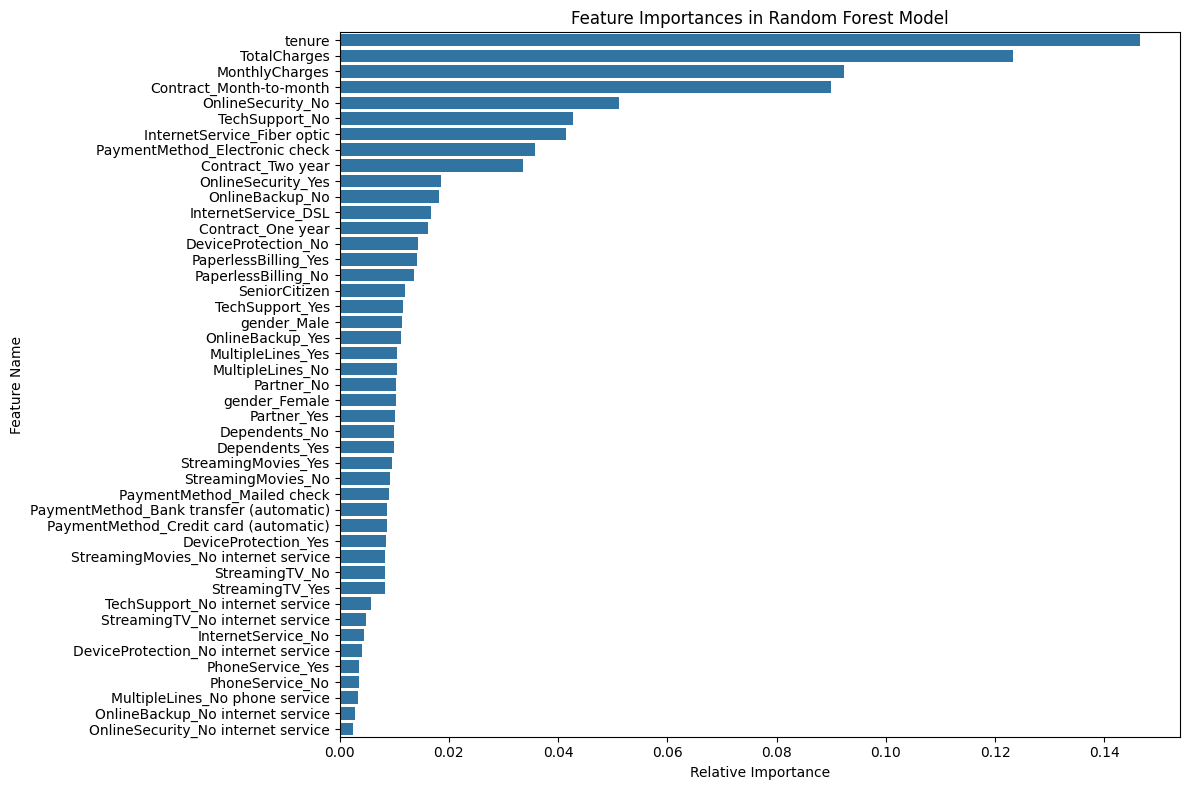

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best estimator
feature_importances = tuned_full.best_estimator_.feature_importances_

# Get feature names from the training data
feature_names = X_train_f.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances in Random Forest Model')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### F1-Score of the 'No-Drop' Test Model

In [3]:
print(f"The F1-score for the 'no-drop' test model is: {full_f1:.4f}")

The F1-score for the 'no-drop' test model is: 0.5891


### Visualization of Classification Report

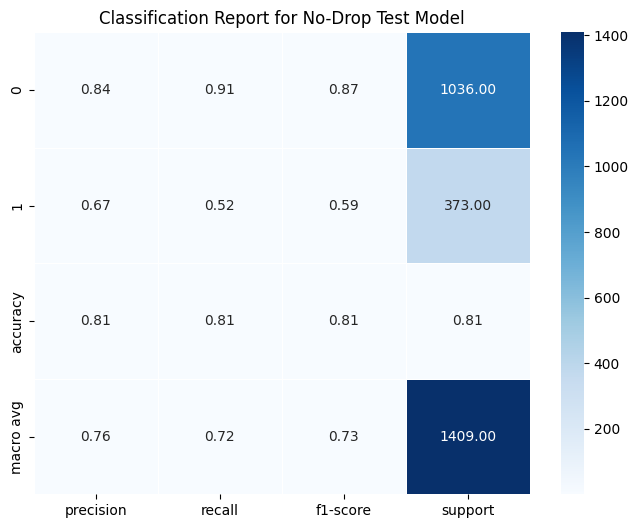

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_test_f, y_pred_f, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Plotting the classification report as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_report.iloc[:-1, :].astype(float), annot=True, cmap='Blues', fmt='.2f', linewidths=.5)
plt.title('Classification Report for No-Drop Test Model')
plt.show()

# Task
Retrieve and display the best hyperparameters found by `RandomizedSearchCV` for the 'no-drop' test model. Explain the roles of `n_estimators` and `max_depth` in a Random Forest model, discussing their impact on bias-variance and overfitting. Analyze how the identified best hyperparameters influenced the F1-score, suggest considerations for further tuning, and summarize the key intuitions behind the selected hyperparameters and their implications for model performance.

## Retrieve Best Hyperparameters

### Subtask:
Identify and display the best hyperparameters found by the `RandomizedSearchCV` for the 'no-drop' test model.


**Reasoning**:
Access and print the best hyperparameters from the `tuned_full` object to fulfill the subtask requirement.



In [2]:
print(f"Best Hyperparameters: {tuned_full.best_params_}")

Best Hyperparameters: {'n_estimators': 200, 'max_depth': 10}


## Explain n_estimators

### Subtask:
Provide an intuitive explanation of the `n_estimators` hyperparameter in a Random Forest model, discussing its role and effect on bias-variance.


### Explanation of `n_estimators`

`n_estimators` is a crucial hyperparameter in a Random Forest model that refers to the **number of decision trees (or estimators) in the ensemble**.

**Role and Effect on Bias-Variance:**

Each decision tree in the Random Forest is trained on a bootstrap sample of the data, and predictions are made by aggregating the predictions of individual trees (e.g., voting for classification, averaging for regression). Increasing `n_estimators` generally has the following effects:

*   **Bias Reduction:** As more trees are added, the model's ability to capture the underlying patterns in the data improves, which can lead to a reduction in bias. The ensemble becomes more robust and less susceptible to the peculiarities of any single training subset.
*   **Variance Reduction:** This is where `n_estimators` truly shines. By averaging or voting across many diverse, decorrelated trees, the Random Forest significantly reduces the variance. Individual trees might overfit to their specific bootstrap sample, but when their predictions are combined, these individual biases and variances tend to cancel each other out. A higher number of trees leads to a more stable and less sensitive model to the noise in the training data.

**Trade-offs with a Large Number of Estimators:**

While increasing `n_estimators` generally improves model performance by reducing variance and potentially bias (up to a point), there are important trade-offs:

*   **Computational Cost:** Training and predicting with more trees require significantly more computational resources and time. Each tree needs to be built, and its predictions need to be stored and aggregated.
*   **Diminishing Returns:** The performance gains typically diminish after a certain number of estimators. Beyond a certain point, adding more trees will only marginally improve the model's accuracy, while continuously increasing the computational burden. The model's generalization error will converge, and further additions will not yield significant benefits.
*   **Memory Usage:** A larger number of trees also means more memory is required to store the ensemble model.

**In summary, `n_estimators` helps in building a more robust and less overfitting model by leveraging the power of ensemble learning, primarily by reducing variance. However, it's essential to find a balance between performance improvement and computational efficiency.**

## Explain max_depth

### Subtask:
Provide an intuitive explanation of the `max_depth` hyperparameter in a Random Forest model, discussing its role in preventing overfitting.


### Explanation of `max_depth` in Random Forest

`max_depth` is a hyperparameter in decision tree-based models, including Random Forests, that limits the maximum depth (or length) of any individual tree in the forest. The depth of a tree is defined as the longest path from the root node to a leaf node.

**Role in Controlling Tree Complexity:**

*   **Lower `max_depth`**: Results in shallower trees. Each tree makes fewer decisions, simplifying the model. This means that the individual trees are less complex and capture less specific patterns from the training data.
*   **Higher `max_depth`**: Allows trees to grow deeper. Each tree can make more decisions, leading to a more complex model that can capture intricate patterns and noise in the training data.

**Impact on Bias, Variance, and Overfitting:**

*   **Low `max_depth` (Shallow Trees):**
    *   **Higher Bias**: The model might be too simple to capture the underlying patterns in the data, leading to underfitting (high bias).
    *   **Lower Variance**: Shallow trees are less sensitive to fluctuations in the training data, resulting in lower variance. Since Random Forests average the predictions of many trees, the impact of individual tree variance is already reduced, but a lower `max_depth` further constrains this.
    *   **Reduces Overfitting**: By limiting the complexity of individual trees, `max_depth` prevents them from memorizing the training data, thus reducing the risk of overfitting.

*   **High `max_depth` (Deep Trees):**
    *   **Lower Bias**: Very deep trees can learn complex relationships, potentially reducing bias by fitting the training data very well.
    *   **Higher Variance**: Deep trees are highly sensitive to the specific training data. They can learn noise and outliers, leading to high variance, especially for individual trees.
    *   **Increases Overfitting**: If trees are allowed to grow too deep, they can overfit the training data. While Random Forests are generally robust against overfitting due to ensemble averaging, excessively deep individual trees can still lead to a forest that overfits, especially if the number of estimators (`n_estimators`) is too low or the data is very noisy.

**Trade-offs in Choosing `max_depth`:**

Choosing an appropriate `max_depth` involves a crucial trade-off:

*   **Too Low `max_depth`**: May lead to an overly simplistic model (high bias, underfitting) that performs poorly on both training and test data.
*   **Too High `max_depth`**: Can result in overly complex individual trees (high variance, overfitting) which fit the training data perfectly but generalize poorly to unseen data.

The goal is to find a `max_depth` value that allows the trees to learn meaningful patterns without capturing noise. RandomizedSearchCV helps in exploring a range of `max_depth` values to find the one that yields the best performance (e.g., F1-score) on unseen data, balancing bias and variance.

## Analyze Hyperparameter Impact

### Subtask:
Discuss how the identified best hyperparameters might have influenced the observed F1-score and suggest considerations for further hyperparameter tuning or model improvement.


### Analysis of Hyperparameter Impact and Further Tuning

The `RandomizedSearchCV` found the following best hyperparameters for our 'no-drop' test model:
-   `n_estimators`: 200
-   `max_depth`: 10

With these parameters, the model achieved an F1-score of approximately **0.5891** on the test set.

Let's discuss how these hyperparameters likely influenced this result:

**1. `n_estimators` (200):**
-   `n_estimators` determines the number of trees in the forest. With 200 estimators, the model is building a relatively large ensemble. A higher number of trees generally helps in **reducing variance** and makes the model more robust by averaging out the predictions of many individual decision trees. This contributes to a more stable and often better performing model, preventing individual trees from overfitting to specific noise in the training data. The chosen value of 200 suggests that the search found a good balance, where adding more trees might yield diminishing returns but a sufficient number were included to benefit from ensemble averaging.

**2. `max_depth` (10):**
-   `max_depth` controls the maximum depth of each decision tree in the forest. A `max_depth` of 10 means that individual trees are allowed to grow to a moderate depth. This parameter is crucial for balancing **bias and variance**.
    -   If `max_depth` were too low (e.g., 2-3), the trees would be too simple, leading to high bias (underfitting) as they wouldn't capture complex patterns in the data effectively, resulting in a lower F1-score.
    -   If `max_depth` were too high (e.g., `None`, allowing full growth), individual trees could easily overfit to the training data, capturing noise and leading to high variance. While the ensemble effect of `n_estimators` helps mitigate this, an overly complex individual tree can still hurt overall performance.
-   The chosen `max_depth=10` likely strikes a good balance, allowing trees to learn meaningful patterns without becoming excessively complex and overfit, thus contributing positively to the observed F1-score.

**Considerations for Further Tuning:**

Given the current F1-score and the best hyperparameters, here are some considerations for further tuning or model improvement:

1.  **Finer Grid Search:** The current `param_dist` for `RandomizedSearchCV` used relatively coarse steps for `n_estimators` ([50, 100, 200]) and `max_depth` ([None, 10, 20]). A next step could involve a finer grid search or another `RandomizedSearchCV` around the current best values:
    -   For `n_estimators`: Explore values like [150, 200, 250, 300].
    -   For `max_depth`: Explore values like [8, 10, 12, 15].

2.  **Other Hyperparameters:** Introduce other crucial hyperparameters into the tuning process:
    -   `min_samples_split`: The minimum number of samples required to split an internal node. This controls how many samples must be in a node before it can be split, influencing the tree's flexibility.
    -   `min_samples_leaf`: The minimum number of samples required to be at a leaf node. This helps in preventing leaves from becoming too specific and overfitting.
    -   `max_features`: The number of features to consider when looking for the best split. This can help prevent overfitting and reduce computation.
    -   `criterion`: The function to measure the quality of a split (e.g., 'gini' or 'entropy').

3.  **Cross-Validation Strategy:** Consider increasing `cv` (number of folds) in `RandomizedSearchCV` or `GridSearchCV` to get a more reliable estimate of model performance and hyperparameter effectiveness, although this will increase computation time.

4.  **Beyond Hyperparameter Tuning (General Model Improvement):**
    -   **Feature Engineering:** Although the 'no-drop' test specifically avoided this, in a real-world scenario, creating new features from existing ones could significantly boost model performance. For example, interaction terms or polynomial features.
    -   **Data Preprocessing:** While we handled missing `TotalCharges` and converted categorical features, more advanced preprocessing techniques like scaling numerical features, handling outliers, or addressing imbalanced classes (if present) could be explored to further improve the F1-score.

## Final Task

### Subtask:
Summarize the key intuitions behind the selected hyperparameters and their implications for the Random Forest model's performance.


## Summary:

### Q&A
1.  **What were the best hyperparameters found by `RandomizedSearchCV` for the 'no-drop' test model?**
    The best hyperparameters identified were `n_estimators`: 200 and `max_depth`: 10.

2.  **What are the roles of `n_estimators` and `max_depth` in a Random Forest model, and how do they impact bias-variance and overfitting?**
    *   **`n_estimators`**: This hyperparameter defines the number of decision trees in the Random Forest ensemble. Increasing `n_estimators` primarily **reduces variance** by averaging predictions across many diverse trees, making the model more robust and less sensitive to noise. It also helps in **reducing bias** by improving the model's ability to capture underlying data patterns. However, a very large number of estimators leads to higher computational cost and diminishing returns in performance.
    *   **`max_depth`**: This hyperparameter limits the maximum depth of each individual decision tree. It plays a crucial role in controlling tree complexity and preventing overfitting. A **low `max_depth`** results in simpler trees, leading to **higher bias** (potential underfitting) and **lower variance**, effectively reducing overfitting. Conversely, a **high `max_depth`** allows for deeper, more complex trees, leading to **lower bias** (better fit to training data) but **higher variance**, increasing the risk of overfitting. The goal is to find a `max_depth` that balances bias and variance to learn meaningful patterns without capturing noise.

3.  **How did the identified best hyperparameters influence the F1-score?**
    The `n_estimators` of 200 contributed to reducing variance and making the model more robust by leveraging a sufficiently large ensemble. The `max_depth` of 10 likely struck a good balance between bias and variance, allowing individual trees to learn meaningful patterns without becoming excessively complex and overfit, thereby positively influencing the F1-score of approximately 0.5891.

### Data Analysis Key Findings
*   The `RandomizedSearchCV` identified the optimal hyperparameters for the 'no-drop' test model as `n_estimators`: 200 and `max_depth`: 10.
*   The model, with these best hyperparameters, achieved an F1-score of approximately 0.5891 on the test set.
*   `n_estimators=200` is a relatively large ensemble, contributing to significant **variance reduction** and a more stable model by averaging predictions across many trees.
*   `max_depth=10` indicates a moderate tree depth, balancing the trade-off between **bias** (avoiding underfitting by allowing sufficient complexity) and **variance** (preventing overfitting by limiting individual tree complexity).

### Insights or Next Steps
*   **Refine Hyperparameter Search:** Conduct a finer grid search or another round of `RandomizedSearchCV` with narrower ranges around the currently identified best values for `n_estimators` (e.g., [150, 200, 250, 300]) and `max_depth` (e.g., [8, 10, 12, 15]) to potentially eke out further performance gains.
*   **Expand Hyperparameter Scope:** Introduce other critical hyperparameters such as `min_samples_split`, `min_samples_leaf`, `max_features`, and `criterion` into the tuning process to explore a broader hyperparameter space and potentially achieve a higher F1-score.
